# Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import seaborn as sns
from pathlib import Path

# Load Dataset

In [26]:
try:
    df = pd.read_csv('../BaseDataset.csv')
    print("Dataset Loaded Successfully.")
    print(df.shape)
except FileNotFoundError:
    print("Error: '../BaseDataset.csv' not found.")

Dataset Loaded Successfully.
(253680, 22)


# Drop duplicates

In [27]:
initial_rows = df.shape[0]
df = df.drop_duplicates()
final_rows = df.shape[0]
print(f"Dropped {initial_rows - final_rows} duplicate rows.\n")

Dropped 23899 duplicate rows.



# correleation matrix

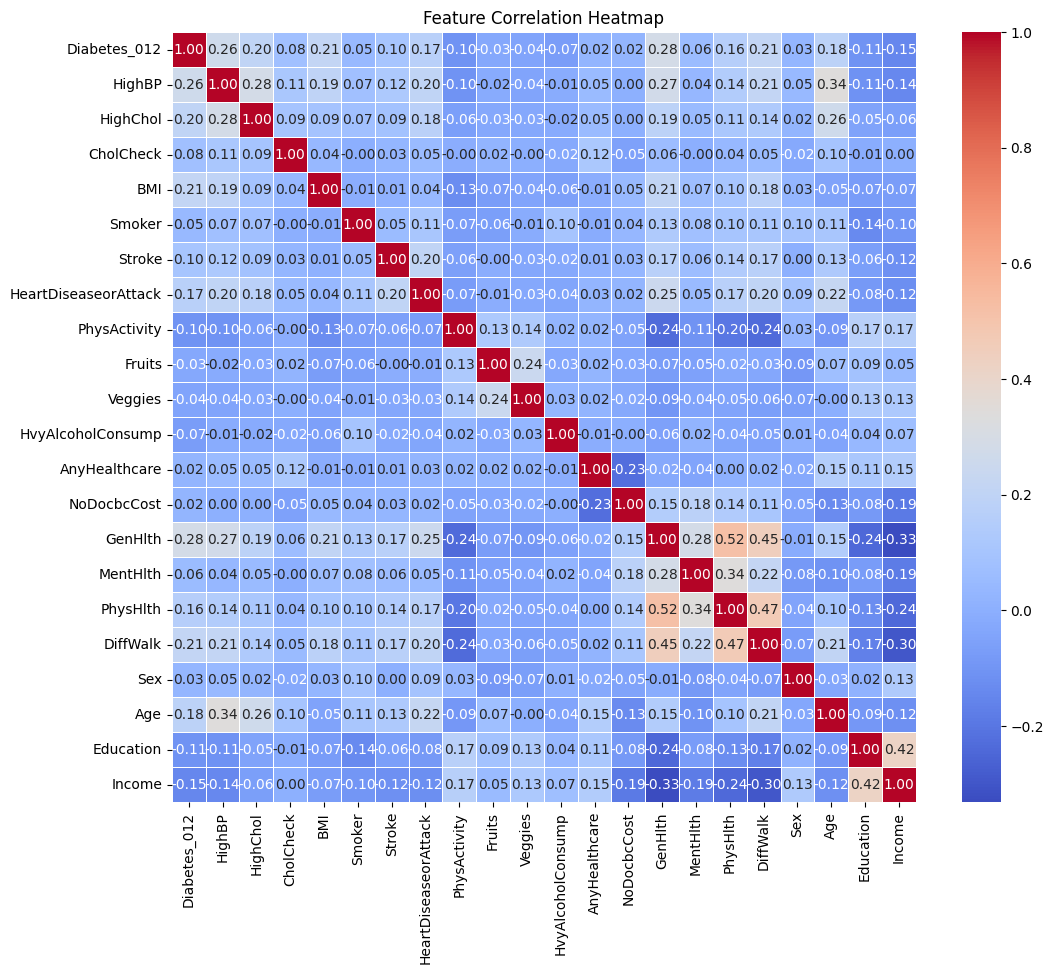

In [28]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Split data

In [29]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(160846, 21) (22978, 21) (45957, 21)


# Compare Order: ANOVA->SMOTE vs SMOTE->ANOVA

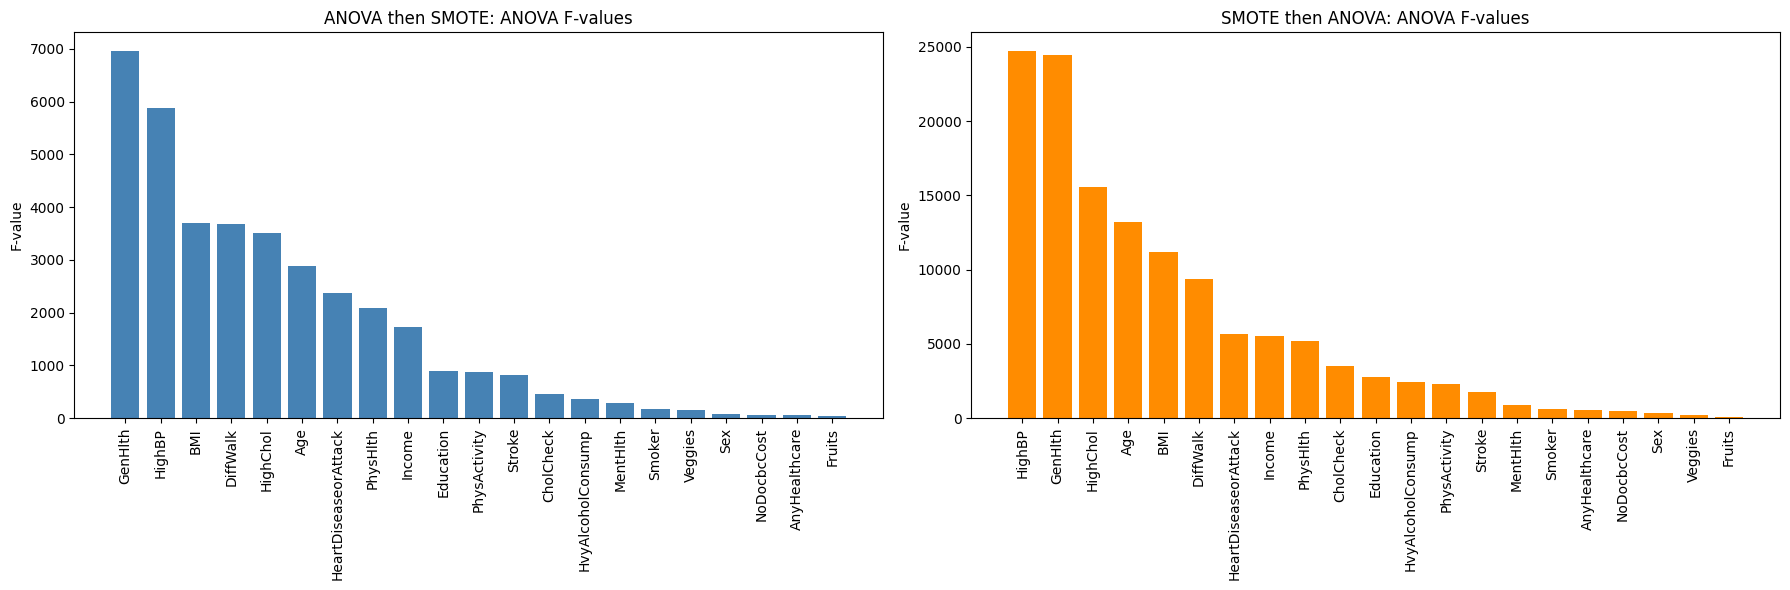

In [30]:
# Keep a copy of scaled training data before any feature selection
X_train_full = X_train.copy()
feature_names = X.columns

# 1) ANOVA first, then SMOTE
selector_anova_first_all = SelectKBest(score_func=f_classif, k='all')
selector_anova_first_all.fit(X_train_full, y_train)
scores_anova_first = selector_anova_first_all.scores_

selector_anova_first_k = SelectKBest(score_func=f_classif, k=9)
X_train_anova_first = selector_anova_first_k.fit_transform(X_train_full, y_train)

smote = SMOTE(random_state=42)
X_train_anova_then_smote, y_train_anova_then_smote = smote.fit_resample(X_train_anova_first, y_train)

# 2) SMOTE first, then ANOVA
X_train_smote_first, y_train_smote_first = smote.fit_resample(X_train_full, y_train)

selector_smote_first_all = SelectKBest(score_func=f_classif, k='all')
selector_smote_first_all.fit(X_train_smote_first, y_train_smote_first)
scores_smote_first = selector_smote_first_all.scores_

selector_smote_first_k = SelectKBest(score_func=f_classif, k=9)
X_train_smote_then_anova = selector_smote_first_k.fit_transform(X_train_smote_first, y_train_smote_first)

# Plot side-by-side ANOVA score comparison
indices_anova_first = np.argsort(scores_anova_first)[::-1]
indices_smote_first = np.argsort(scores_smote_first)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(range(len(scores_anova_first)), scores_anova_first[indices_anova_first], color='steelblue')
axes[0].set_xticks(range(len(scores_anova_first)))
axes[0].set_xticklabels(feature_names[indices_anova_first], rotation=90)
axes[0].set_title('ANOVA then SMOTE: ANOVA F-values')
axes[0].set_ylabel('F-value')

axes[1].bar(range(len(scores_smote_first)), scores_smote_first[indices_smote_first], color='darkorange')
axes[1].set_xticks(range(len(scores_smote_first)))
axes[1].set_xticklabels(feature_names[indices_smote_first], rotation=90)
axes[1].set_title('SMOTE then ANOVA: ANOVA F-values')
axes[1].set_ylabel('F-value')

plt.tight_layout()
plt.show()

### ANOVA then SMOTE is the better choice as SMOTE creates synthetic data points by strictly connecting the dots between existing minority class points.
### Because these new points are perfectly placed between existing points, the "Within-Group Variance" (the denominator) shrinks artificially close to zero.

In [33]:
# Save ANOVA -> SMOTE training datasets, and untouched validation/test datasets, for multiple k values
k_values = [9, 12, 21]

# Recreate train/val/test splits only if needed
required_vars = {'X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test'}
if not required_vars.issubset(set(globals().keys())):
    target_candidates = ['Diabetes_012']
    target_col = next((c for c in target_candidates if c in df.columns), df.columns[-1])
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
    )

X_train_full = X_train.copy()
feature_names_full = X_train_full.columns
target_name = y_train.name if getattr(y_train, 'name', None) else 'Diabetes_012'
output_dir = Path('.')
saved_info = []

for k in k_values:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_anova = selector.fit_transform(X_train_full, y_train)
    selected_feature_names = feature_names_full[selector.get_support(indices=True)]

    # SMOTE is applied only to training data
    X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train_anova, y_train)

    train_df = pd.DataFrame(X_train_smote, columns=selected_feature_names)
    train_df[target_name] = np.asarray(y_train_smote)

    # Validation/Test are transformed with the same selector but kept untouched (no SMOTE)
    X_val_sel = selector.transform(X_val)
    X_test_sel = selector.transform(X_test)

    val_df = pd.DataFrame(X_val_sel, columns=selected_feature_names)
    val_df[target_name] = np.asarray(y_val)

    test_df = pd.DataFrame(X_test_sel, columns=selected_feature_names)
    test_df[target_name] = np.asarray(y_test)

    train_file = output_dir / f'Smote_k{k}.csv'
    val_file = output_dir / f'Smote_Val_k{k}.csv'
    test_file = output_dir / f'Smote_Test_k{k}.csv'

    train_df.to_csv(train_file, index=False)
    val_df.to_csv(val_file, index=False)
    test_df.to_csv(test_file, index=False)

    saved_info.append({
        'k': k,
        'train_shape': train_df.shape,
        'val_shape': val_df.shape,
        'test_shape': test_df.shape,
        'train_path': train_file.resolve(),
        'val_path': val_file.resolve(),
        'test_path': test_file.resolve()
    })

for item in saved_info:
    print(f"k={item['k']} -> train {item['train_shape']} | val {item['val_shape']} | test {item['test_shape']}")
    print(f"  train: {item['train_path']}")
    print(f"  val:   {item['val_path']}")
    print(f"  test:  {item['test_path']}")
print(f"Target column in saved files: {target_name}")

k=9 -> train (399114, 10) | val (22978, 10) | test (45957, 10)
  train: /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_k9.csv
  val:   /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_Val_k9.csv
  test:  /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_Test_k9.csv
k=12 -> train (399114, 13) | val (22978, 13) | test (45957, 13)
  train: /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_k12.csv
  val:   /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_Val_k12.csv
  test:  /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_Test_k12.csv
k=21 -> train (399114, 22) | val (22978, 22) | test (45957, 22)
  train: /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_k21.csv
  val:   /home/ali/Desktop/GitProjects/diabetes-risk-prediction/datasets/oversampling/Smote_Va

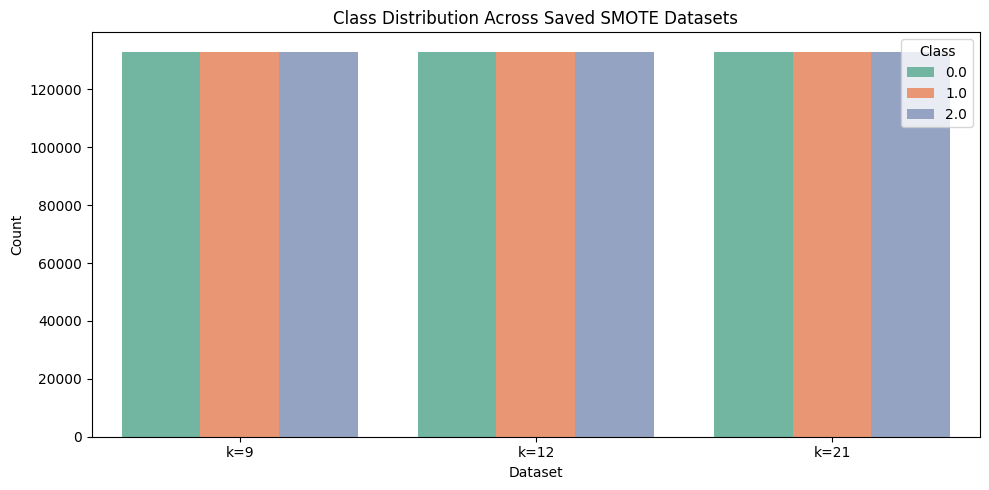

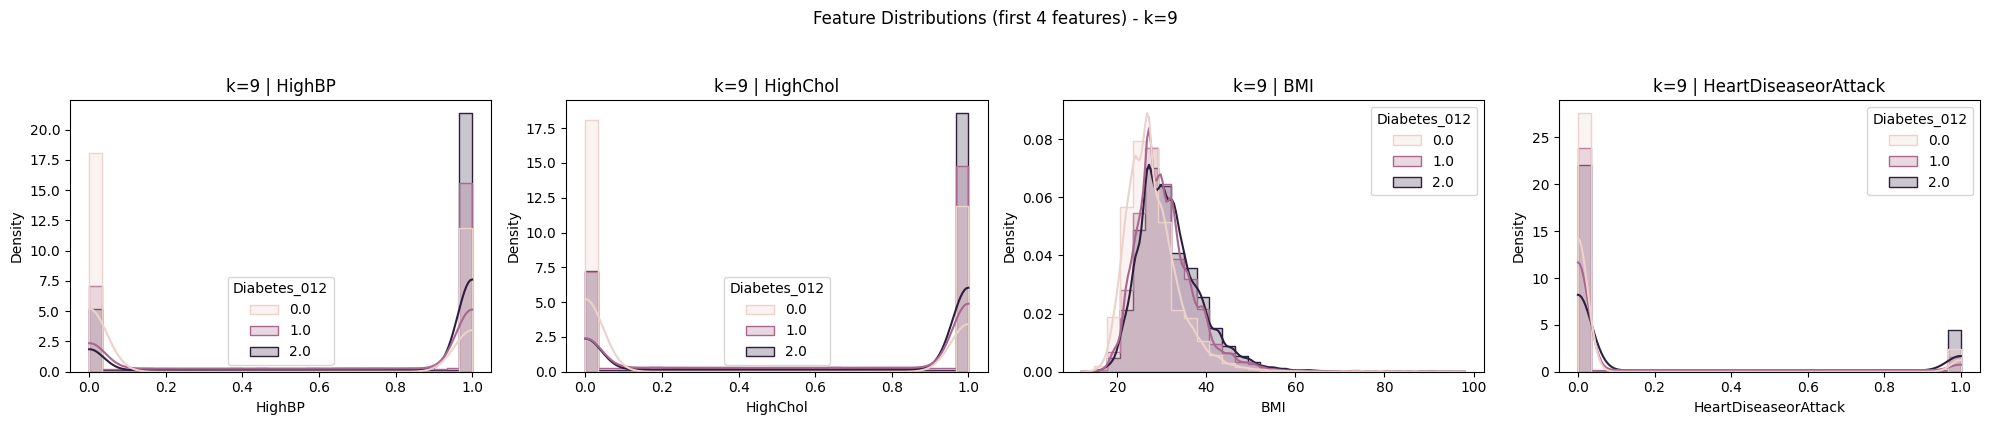

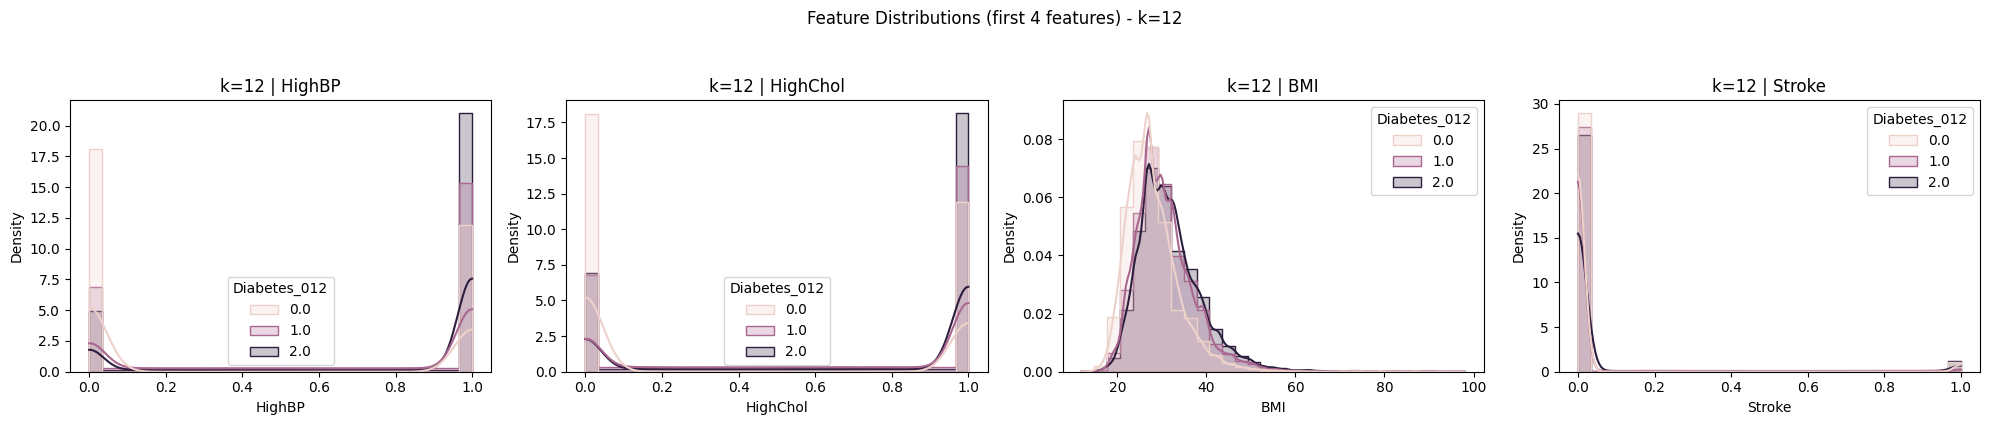

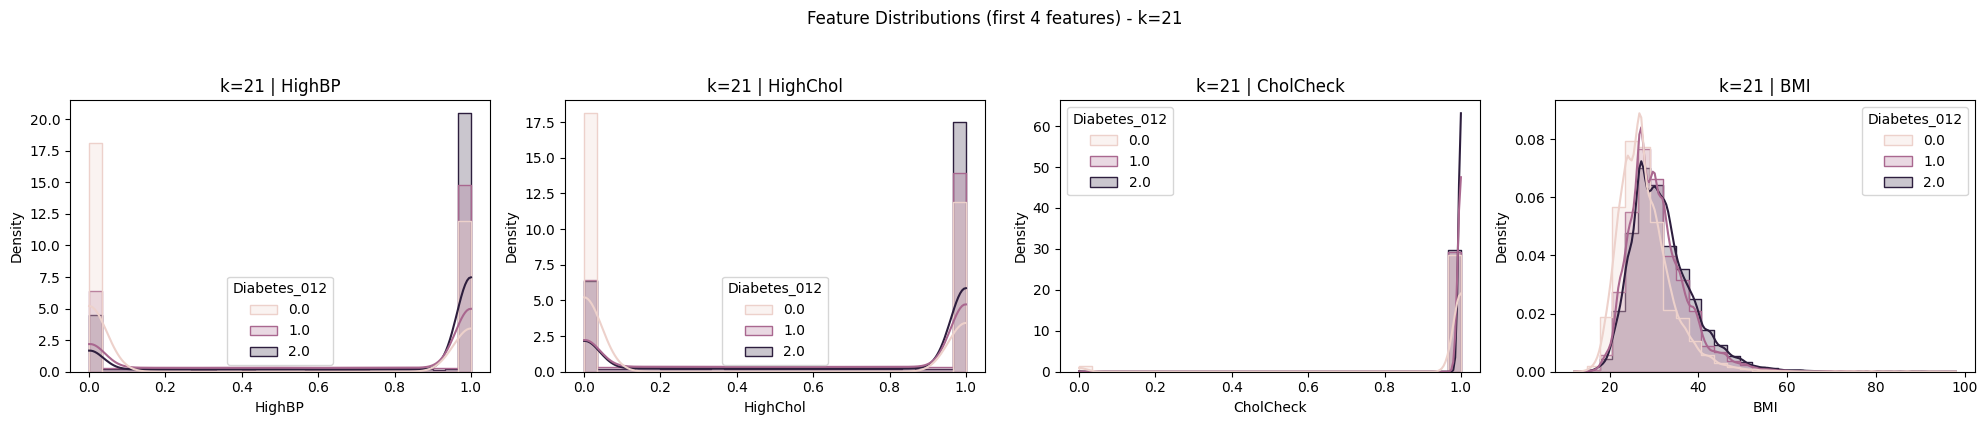

In [32]:
csv_paths = {
    9: Path('Smote_k9.csv'),
    12: Path('Smote_k12.csv'),
    21: Path('Smote_k21.csv')
}

datasets = {}
target_candidates = ['Diabetes_012']

for k, path in csv_paths.items():
    if not path.exists():
        print(f'Missing file: {path.resolve()}')
        continue
    dset = pd.read_csv(path)
    target_col = next((c for c in target_candidates if c in dset.columns), dset.columns[-1])
    datasets[k] = {'df': dset, 'target_col': target_col}

if len(datasets) == 0:
    raise FileNotFoundError('No saved CSV files were found. Run the save cell first.')

# Plot 1: class distribution for each dataset
class_rows = []
for k, item in datasets.items():
    vc = item['df'][item['target_col']].value_counts().sort_index()
    for cls, count in vc.items():
        class_rows.append({'k': f'k={k}', 'class': str(cls), 'count': int(count)})

class_dist_df = pd.DataFrame(class_rows)
plt.figure(figsize=(10, 5))
sns.barplot(data=class_dist_df, x='k', y='count', hue='class', palette='Set2')
plt.title('Class Distribution Across Saved SMOTE Datasets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

# Plot 2: feature distributions (histograms) for each dataset
for k, item in datasets.items():
    dset = item['df']
    target_col = item['target_col']
    feature_cols = [c for c in dset.columns if c != target_col][:4]

    if len(feature_cols) == 0:
        print(f'No feature columns found in dataset k={k}.')
        continue

    n = len(feature_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, feature_cols):
        sns.histplot(data=dset, x=col, hue=target_col, bins=30, kde=True, ax=ax, element='step', stat='density', common_norm=False)
        ax.set_title(f'k={k} | {col}')

    fig.suptitle(f'Feature Distributions (first {n} features) - k={k}', y=1.05)
    plt.tight_layout()
    plt.show()